# Discrete Time Quantum Walk

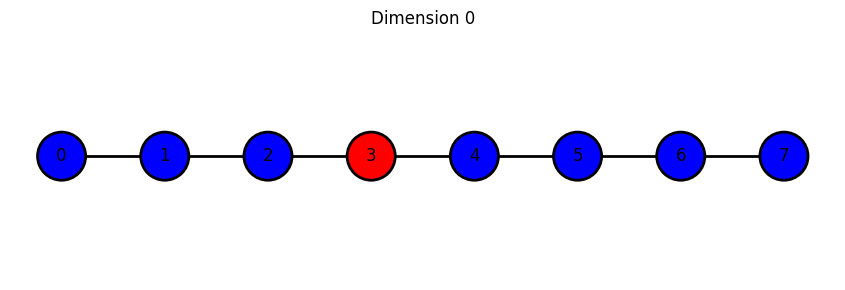

In [ ]:
import os
import sys

sys.path.append(os.path.abspath(".."))
from qlauncher.problems import DTQW_ND
from qlauncher.routines.qiskit.algorithms.quantum_walk import CoinType

coin_type = CoinType.HADAMARD
no_steps = 3
no_pos_qubits = 3
no_coin_qubits = 1
initial_position = (1, 3) # (Coin position, Walker position)

problem = DTQW_ND([[coin_type, no_steps, no_pos_qubits, no_coin_qubits, initial_position, False]], "DTQW 1D")

problem.visualize()

In [2]:
from qlauncher.launcher import QLauncher
from qlauncher.routines.qiskit import QiskitBackend
from qlauncher.routines.qiskit.algorithms import DiscreteTimeQuantumWalk

solution = QLauncher(problem, DiscreteTimeQuantumWalk(), QiskitBackend('local_simulator')).run()

[{'shots': 1024, 'circuit_metadata': {}, 'sampler_version': 2}]
{'0100': 537.0, '1100': 119.0, '0110': 120.0, '0010': 128.0, '1000': 120.0}


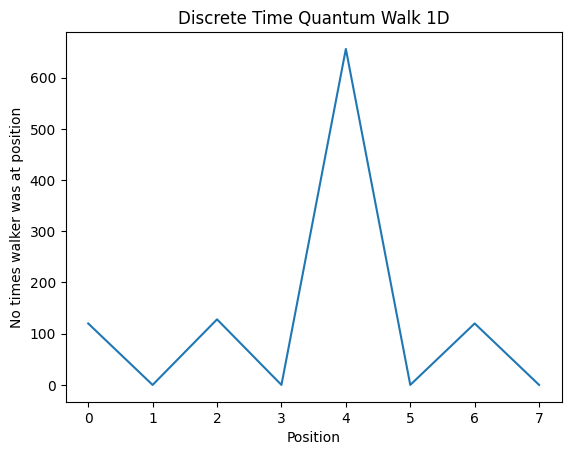

In [3]:
from qlauncher.routines.qiskit.algorithms import QW_Helper

quasi_dist = solution.result.quasi_dists
metadata = solution.result.metadata
print(metadata)
shots = metadata[0].get("shots")
width = max(quasi_dist[0].keys()).bit_length()

normal_dist = {
    format(state, f"0{width}b"): prob * shots
    for state, prob in quasi_dist[0].items()
}
print(normal_dist)
qw_helper = QW_Helper()

qw_helper.display_res_with_coin(normal_dist, 0, 2**no_pos_qubits, "Discrete Time Quantum Walk 1D")

# Discrete Time Quantum Walk with Shunt Decomposition

In [ ]:
problem = DTQW_ND([[coin_type, no_steps, no_pos_qubits, no_coin_qubits, initial_position, True]], "DTQW 1D")
problem.visualize()

TypeError: 'CoinType' object is not subscriptable

Result(bitstring=, energy=1)
[{'shots': 1024, 'circuit_metadata': {}, 'sampler_version': 2}]
[{4: 0.4755859375, 8: 0.140625, 6: 0.125, 2: 0.140625, 12: 0.1181640625}]
{'0100': 487.0, '1000': 144.0, '0110': 128.0, '0010': 144.0, '1100': 121.0}


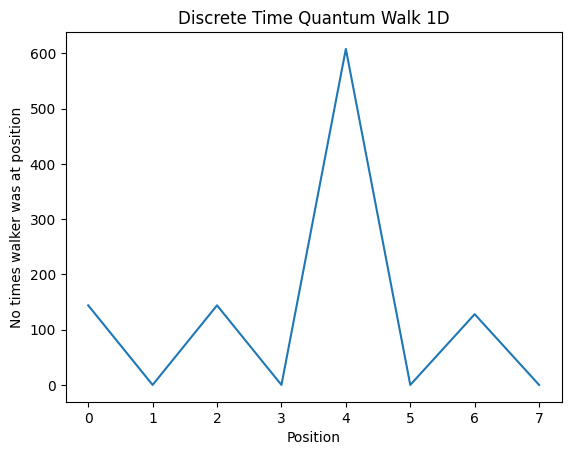

In [ ]:
problem = DTQW_ND([[coin_type, no_steps, no_pos_qubits, no_coin_qubits, initial_position, True]], "DTQW 1D")
solution = QLauncher(problem, DiscreteTimeQuantumWalk(), QiskitBackend('local_simulator')).run()
print(solution)
quasi_dist = solution.result.quasi_dists
metadata = solution.result.metadata
print(metadata)
shots = metadata[0].get("shots")
width = max(quasi_dist[0].keys()).bit_length()

normal_dist = {
    format(state, f"0{width}b"): prob * shots
    for state, prob in quasi_dist[0].items()
}
print(quasi_dist)
print(normal_dist)
qw_helper = QW_Helper()

qw_helper.display_res_with_coin(normal_dist, 0, 2**no_pos_qubits, "Discrete Time Quantum Walk 1D")